Task-1  Social Media Trend Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sentimentdataset.csv")
df

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB
None


In [ ]:
df.drop_duplicates(inplace=True)
df

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [ ]:
print(df.isnull().sum())

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [ ]:
df.dropna(subset=['Text'], inplace=True)
df

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [ ]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

In [ ]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    return text.lower().strip()

df["cleaned_text"] = df["Text"].apply(clean_text)

In [ ]:
from textblob import TextBlob

# Function to classify sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["cleaned_text"].apply(get_sentiment)

# Display sentiment distribution
print(df["sentiment"].value_counts())


sentiment
Neutral     325
Positive    283
Negative    124
Name: count, dtype: int64


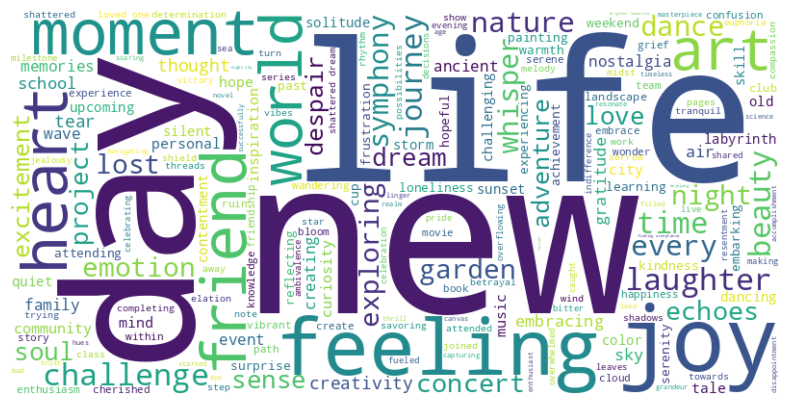

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all text
all_words = " ".join(df["cleaned_text"])

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


<ipython-input-16-5114353099e2>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["sentiment"], palette="coolwarm")


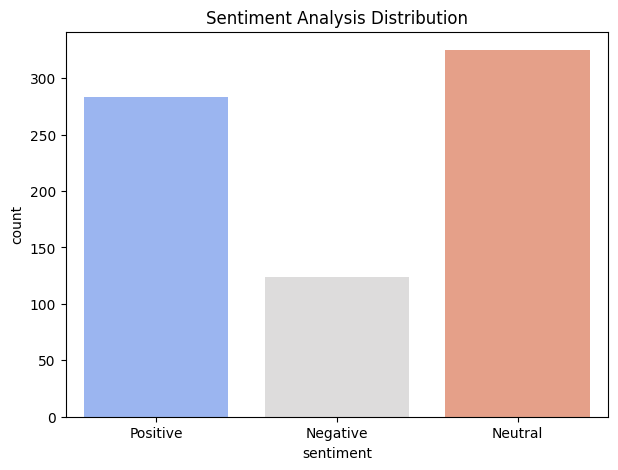

In [ ]:
import seaborn as sns

# Plot sentiment count
plt.figure(figsize=(7,5))
sns.countplot(x=df["sentiment"], palette="coolwarm")
plt.title("Sentiment Analysis Distribution")
plt.show()


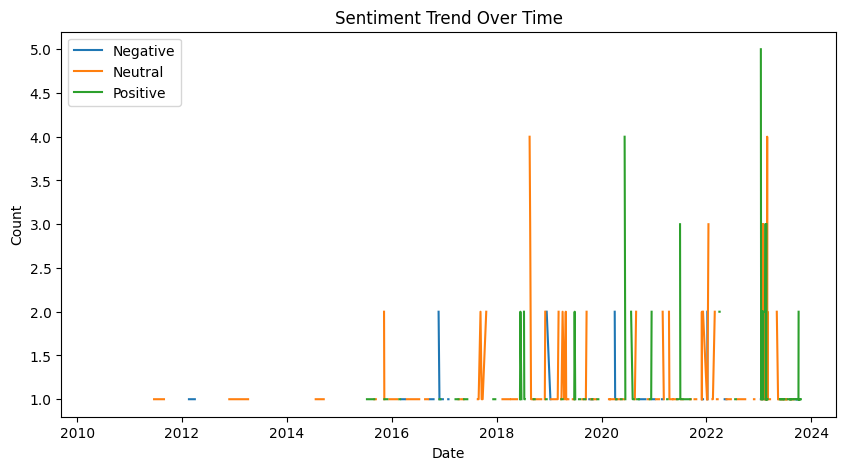

In [ ]:
# Convert timestamp to datetime format
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Group sentiment over time
df.groupby([df["Timestamp"].dt.date, "sentiment"])["Text"].count().unstack().plot(kind="line", figsize=(10,5))

plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend(["Negative", "Neutral", "Positive"])
plt.show()


In [ ]:
df.to_csv("processed_sentiment_data.csv", index=False)


In [ ]:
import os

# Check if file exists in the current directory
print("Files in directory:", os.listdir())


Files in directory: ['.config', 'customer_support_tickets.csv', 'processed_sentiment_data.csv', 'sentimentdataset.csv', 'sample_data']


In [ ]:
from google.colab import files

# Download the processed file
files.download("processed_sentiment_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task-2
Customer Support Ticket Dataset

In [ ]:
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("/content/customer_support_tickets.csv")


In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)


In [ ]:
df['cleaned_description'] = df['Ticket Description'].apply(preprocess)


In [ ]:
all_words = ' '.join(df['cleaned_description']).split()
word_freq = Counter(all_words)
top_15 = word_freq.most_common(15)


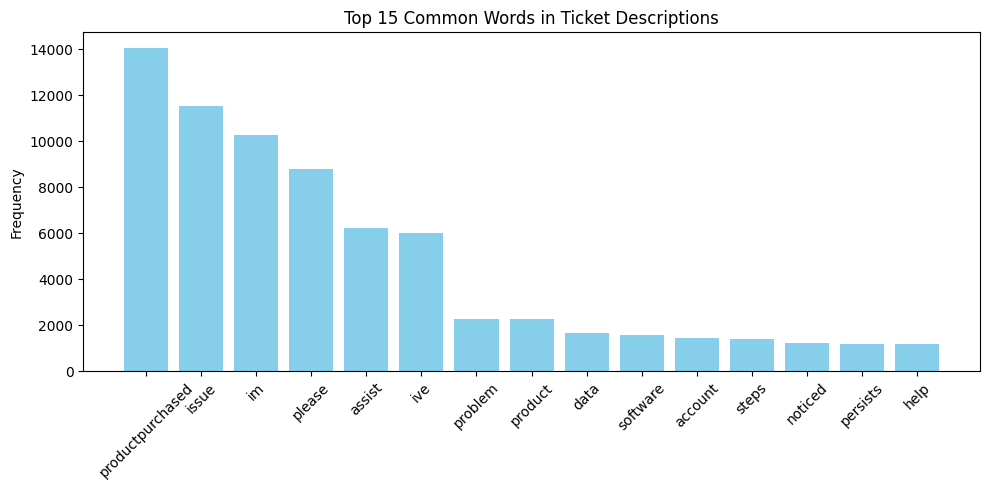

In [ ]:
words, counts = zip(*top_15)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='skyblue')
plt.title('Top 15 Common Words in Ticket Descriptions')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
top_keywords = [word for word, _ in top_15]

def categorize_issue(text):
    for keyword in top_keywords:
        if keyword in text:
            return keyword
    return 'other'

df['issue_category'] = df['cleaned_description'].apply(categorize_issue)


In [ ]:
df['First Response Time'] = pd.to_numeric(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')
df['Customer Satisfaction Rating'] = pd.to_numeric(df['Customer Satisfaction Rating'], errors='coerce')


In [ ]:
time_stats = df.groupby('issue_category')[['First Response Time', 'Time to Resolution']].mean()


In [ ]:
satisfaction_stats = df.groupby('issue_category')['Customer Satisfaction Rating'].mean()


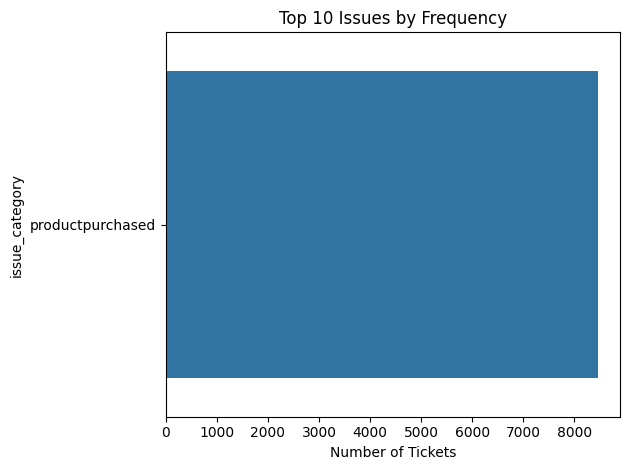

In [ ]:
issue_counts = df['issue_category'].value_counts().head(10)
sns.barplot(x=issue_counts.values, y=issue_counts.index)
plt.title('Top 10 Issues by Frequency')
plt.xlabel('Number of Tickets')
plt.tight_layout()
plt.show()


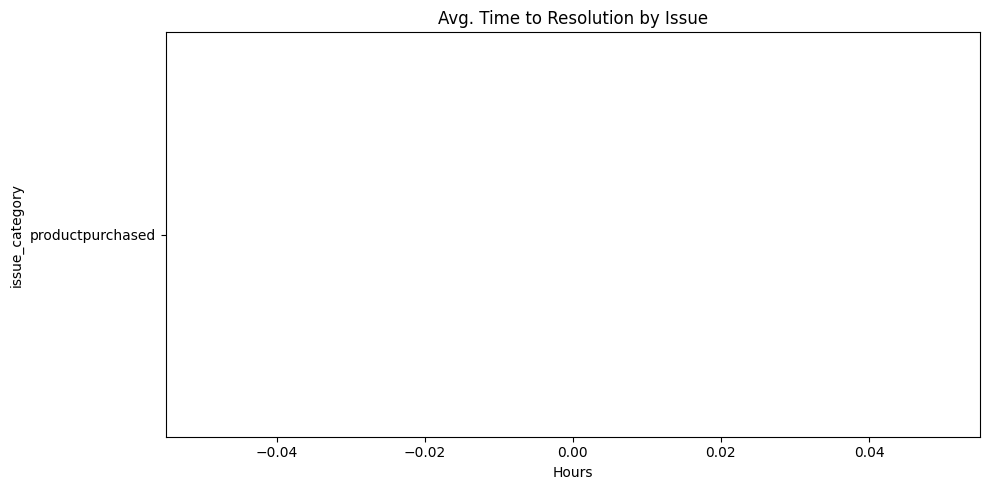

In [ ]:
time_stats['Time to Resolution'].plot(kind='barh', title='Avg. Time to Resolution by Issue', figsize=(10, 5))
plt.xlabel('Hours')
plt.tight_layout()
plt.show()


In [ ]:
longest_resolution = time_stats.sort_values(by='Time to Resolution', ascending=False).head(5)
lowest_satisfaction = satisfaction_stats.sort_values().head(5)
merged_stats = time_stats.join(satisfaction_stats, how='inner')
pain_points = merged_stats.sort_values(by=['Time to Resolution', 'Customer Satisfaction Rating'], ascending=[False, True]).head(5)


In [ ]:
print("🔹 Top 5 Issues with Longest Resolution Times:")
print(longest_resolution)

print("\n🔹 Top 5 Issues with Lowest Customer Satisfaction:")
print(lowest_satisfaction)

print("\n🔹 Pain Points (Slow & Low Satisfaction):")
print(pain_points)


🔹 Top 5 Issues with Longest Resolution Times:
                  First Response Time  Time to Resolution
issue_category                                           
productpurchased                  NaN                 NaN

🔹 Top 5 Issues with Lowest Customer Satisfaction:
issue_category
productpurchased    2.991333
Name: Customer Satisfaction Rating, dtype: float64

🔹 Pain Points (Slow & Low Satisfaction):
                  First Response Time  Time to Resolution  \
issue_category                                              
productpurchased                  NaN                 NaN   

                  Customer Satisfaction Rating  
issue_category                                  
productpurchased                      2.991333  


In [ ]:
print("\n📋 Summary Report:")
print("Most common support issues have been categorized and analyzed.")
print(f"- Issue categories such as {', '.join(longest_resolution.index[:3])} have the longest resolution times.")
print(f"- Categories like {', '.join(lowest_satisfaction.index[:3])} receive the lowest customer satisfaction scores.")
print("Recommendations:")

for issue in pain_points.index:
    print(f"- Consider creating automated responses or guided workflows for **'{issue}'** issues to reduce resolution time and improve satisfaction.")



📋 Summary Report:
Most common support issues have been categorized and analyzed.
- Issue categories such as productpurchased have the longest resolution times.
- Categories like productpurchased receive the lowest customer satisfaction scores.
Recommendations:
- Consider creating automated responses or guided workflows for **'productpurchased'** issues to reduce resolution time and improve satisfaction.


Task-3
